In [5]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [6]:
from LSTM import Seq2SeqLSTM

In [7]:
csv_path = os.path.join('dataset', 'data_final.csv')

dataset = pd.read_csv(
    csv_path,
    index_col='Date',
    parse_dates=['Date']
)

dataset.head()

,전력량,공장 인원,Weekend,Vacation,time_sin,time_cos,day_sin,day_cos
Date,,,,,,,,
2021-01-01 00:15:00,62.0,0.0,0.0,0.0,0.065403,0.997859,-0.433884,-0.900969
2021-01-01 00:30:00,61.0,0.0,0.0,0.0,0.130526,0.991445,-0.433884,-0.900969
2021-01-01 00:45:00,61.0,0.0,0.0,0.0,0.195090,0.980785,-0.433884,-0.900969
2021-01-01 01:00:00,61.0,0.0,0.0,0.0,0.258819,0.965926,-0.433884,-0.900969
2021-01-01 01:15:00,96.0,0.0,0.0,0.0,0.321439,0.946930,-0.433884,-0.900969


In [8]:
idx = dataset.index

split1 = idx[int(len(idx) * 0.6)].ceil('D')
split2 = idx[int(len(idx) * 0.8)].ceil('D')

print(f'검증 셋 기준 날짜 : {split1}')
print(f'테스트 셋 기준 날짜 : {split2}')

검증 셋 기준 날짜 : 2021-06-05 00:00:00
테스트 셋 기준 날짜 : 2021-07-26 00:00:00


In [9]:
power_scaler = StandardScaler()
people_scaler = StandardScaler()

train_mask = idx < split1

power_scaler.fit(dataset.loc[train_mask, ['전력량']])
people_scaler.fit(dataset.loc[train_mask, ['공장 인원']])

dataset_scaled = dataset.copy()

dataset_scaled[['전력량']] = power_scaler.transform(
    dataset[['전력량']]
)

dataset_scaled[['공장 인원']] = people_scaler.transform(
    dataset[['공장 인원']]
)

In [10]:
def make_sequences(data, window_size=96, horizon=96):
    feature_data = data.values
    target_data = data['전력량'].values

    X, y = [], []
    for i in range(window_size, len(data) - horizon + 1):
        X.append(feature_data[i - window_size : i])   
        y.append(target_data[i : i+horizon])       

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [11]:
window_size = 96
horizon_size = 96
X, y = make_sequences(dataset_scaled, window_size, horizon_size)

t_start = dataset_scaled.index[window_size : len(dataset_scaled) - horizon_size + 1]  
t_end   = dataset_scaled.index[window_size + horizon_size - 1 :]   

In [12]:
train_split = t_end < split1
valid_split = (t_start >= split1) & (t_end < split2)
test_split  = t_start >= split2

X_train, y_train = X[train_split], y[train_split]
X_valid, y_valid = X[valid_split], y[valid_split]
X_test,  y_test  = X[test_split],  y[test_split]


print(f'훈련 셋 X : {X_train.shape}, y : {y_train.shape}')
print(f'검증 셋 X : {X_valid.shape}, y : {y_valid.shape}')
print(f'테스트 셋 X : {X_test.shape}, y : {y_test.shape}')

훈련 셋 X : (14688, 96, 8), y : (14688, 96)
검증 셋 X : (4801, 96, 8), y : (4801, 96)
테스트 셋 X : (4802, 96, 8), y : (4802, 96)


In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_valid = torch.tensor(X_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [14]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = Seq2SeqLSTM(
    input_size=X_train.size(2),
    hidden_size=128,
    num_layers=2,
    output_size=96,
).to(device)

In [16]:
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
num_epoch = 150

In [ ]:
train_loss_graph = []
valid_loss_graph = []

patience = 20
best_valid_loss = float('inf')
patience_count = 0

for epoch in range(num_epoch):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
        optimizer.step()
        train_loss += loss.item()

    model.eval()

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            valid_loss += loss.item()

    train_loss /= len(train_loader)
    valid_loss /= len(valid_loader)

    train_loss_graph.append(train_loss)
    valid_loss_graph.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_count = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        patience_count += 1

    if epoch % 10 == 0:
        print(
            f'[epoch: {epoch}] '
            f'train loss: {train_loss:.4f}, '
            f'valid loss: {valid_loss:.4f}'
        )

    if patience_count >= patience:
        print(f'Early stopping at epoch {epoch}\n train loss: {train_loss:.4f}, '
              f'valid loss: {valid_loss:.4f}')
        break

[epoch: 0] train loss: 0.4287, valid loss: 0.2860
[epoch: 10] train loss: 0.2129, valid loss: 0.1479
[epoch: 20] train loss: 0.1882, valid loss: 0.1356
[epoch: 30] train loss: 0.1719, valid loss: 0.1443
Early stopping at epoch 37
 train loss: 0.1985, valid loss: 0.1481


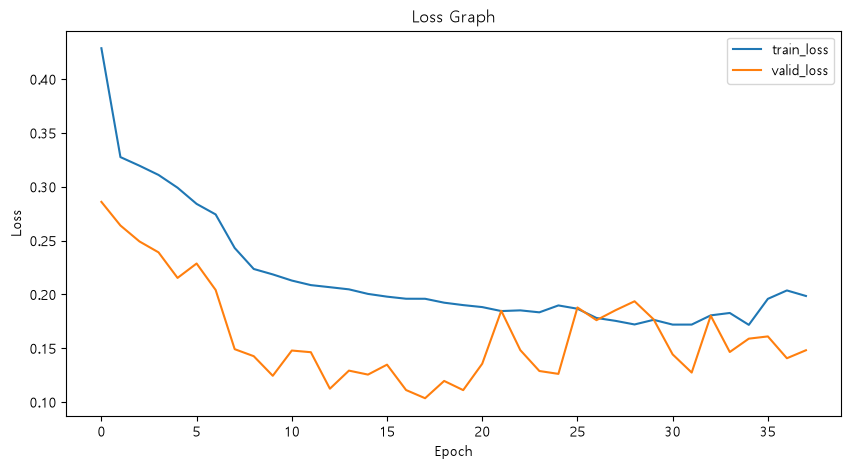

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_graph, label='train_loss')
plt.plot(valid_loss_graph, label='valid_loss')
plt.legend()
plt.title('Loss Graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [19]:
model.load_state_dict(best_model)
model.eval()

pred_graph = []
y_graph = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)

        pred_transform = power_scaler.inverse_transform(
            pred.detach().cpu().numpy().reshape(-1, 1)
        ).reshape(-1, horizon_size)
        y_transform = power_scaler.inverse_transform(
            y.detach().cpu().numpy().reshape(-1, 1)
        ).reshape(-1, horizon_size)

        pred_graph.append(pred_transform)
        y_graph.append(y_transform)

pred_graph = np.concatenate(pred_graph, axis=0)
y_graph = np.concatenate(y_graph, axis=0)
loss = y_graph - pred_graph

print(f'예측 shape : {pred_graph.shape}')

예측 shape : (4802, 96)


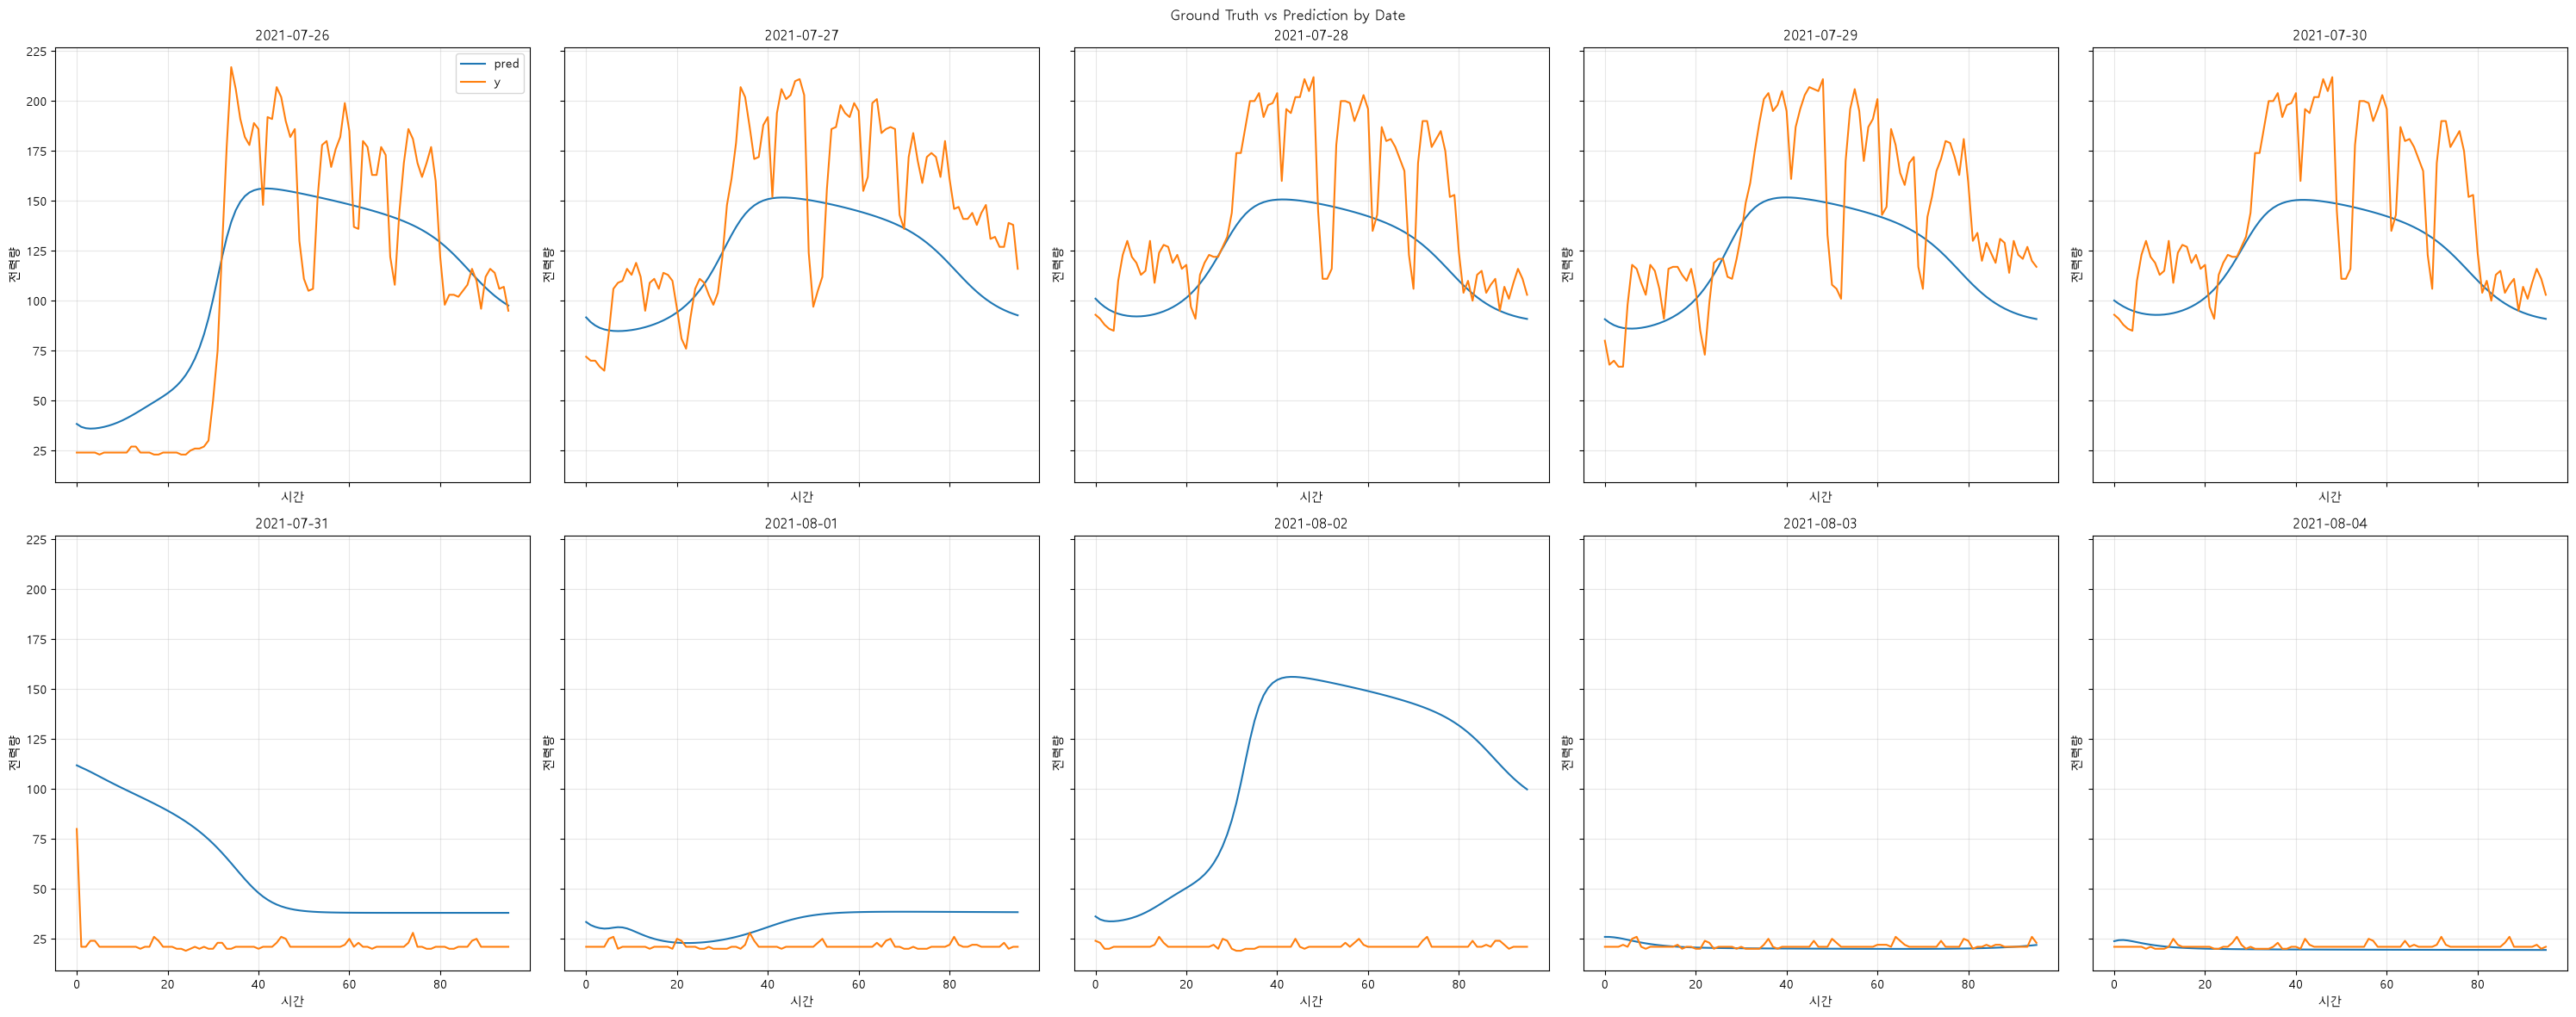

In [22]:
test_dates = t_start[test_split][:len(pred_graph)]
daily_dates = test_dates.normalize()
_, first_indices = np.unique(daily_dates, return_index=True)
first_indices = np.sort(first_indices)
num_days = min(10, len(first_indices))
fig, axes = plt.subplots(2, 5, figsize=(30, 12), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat[:num_days]):
    sample_idx = first_indices[i]
    ax.plot(pred_graph[sample_idx], label='pred')
    ax.plot(y_graph[sample_idx], label='y')
    ax.set_title(test_dates[sample_idx].strftime('%Y-%m-%d'))
    ax.set_xlabel('시간')
    ax.set_ylabel('전력량')
    ax.grid(alpha=0.3)

axes.flat[0].legend()
fig.suptitle('Ground Truth vs Prediction by Date')
fig.tight_layout()
plt.show()

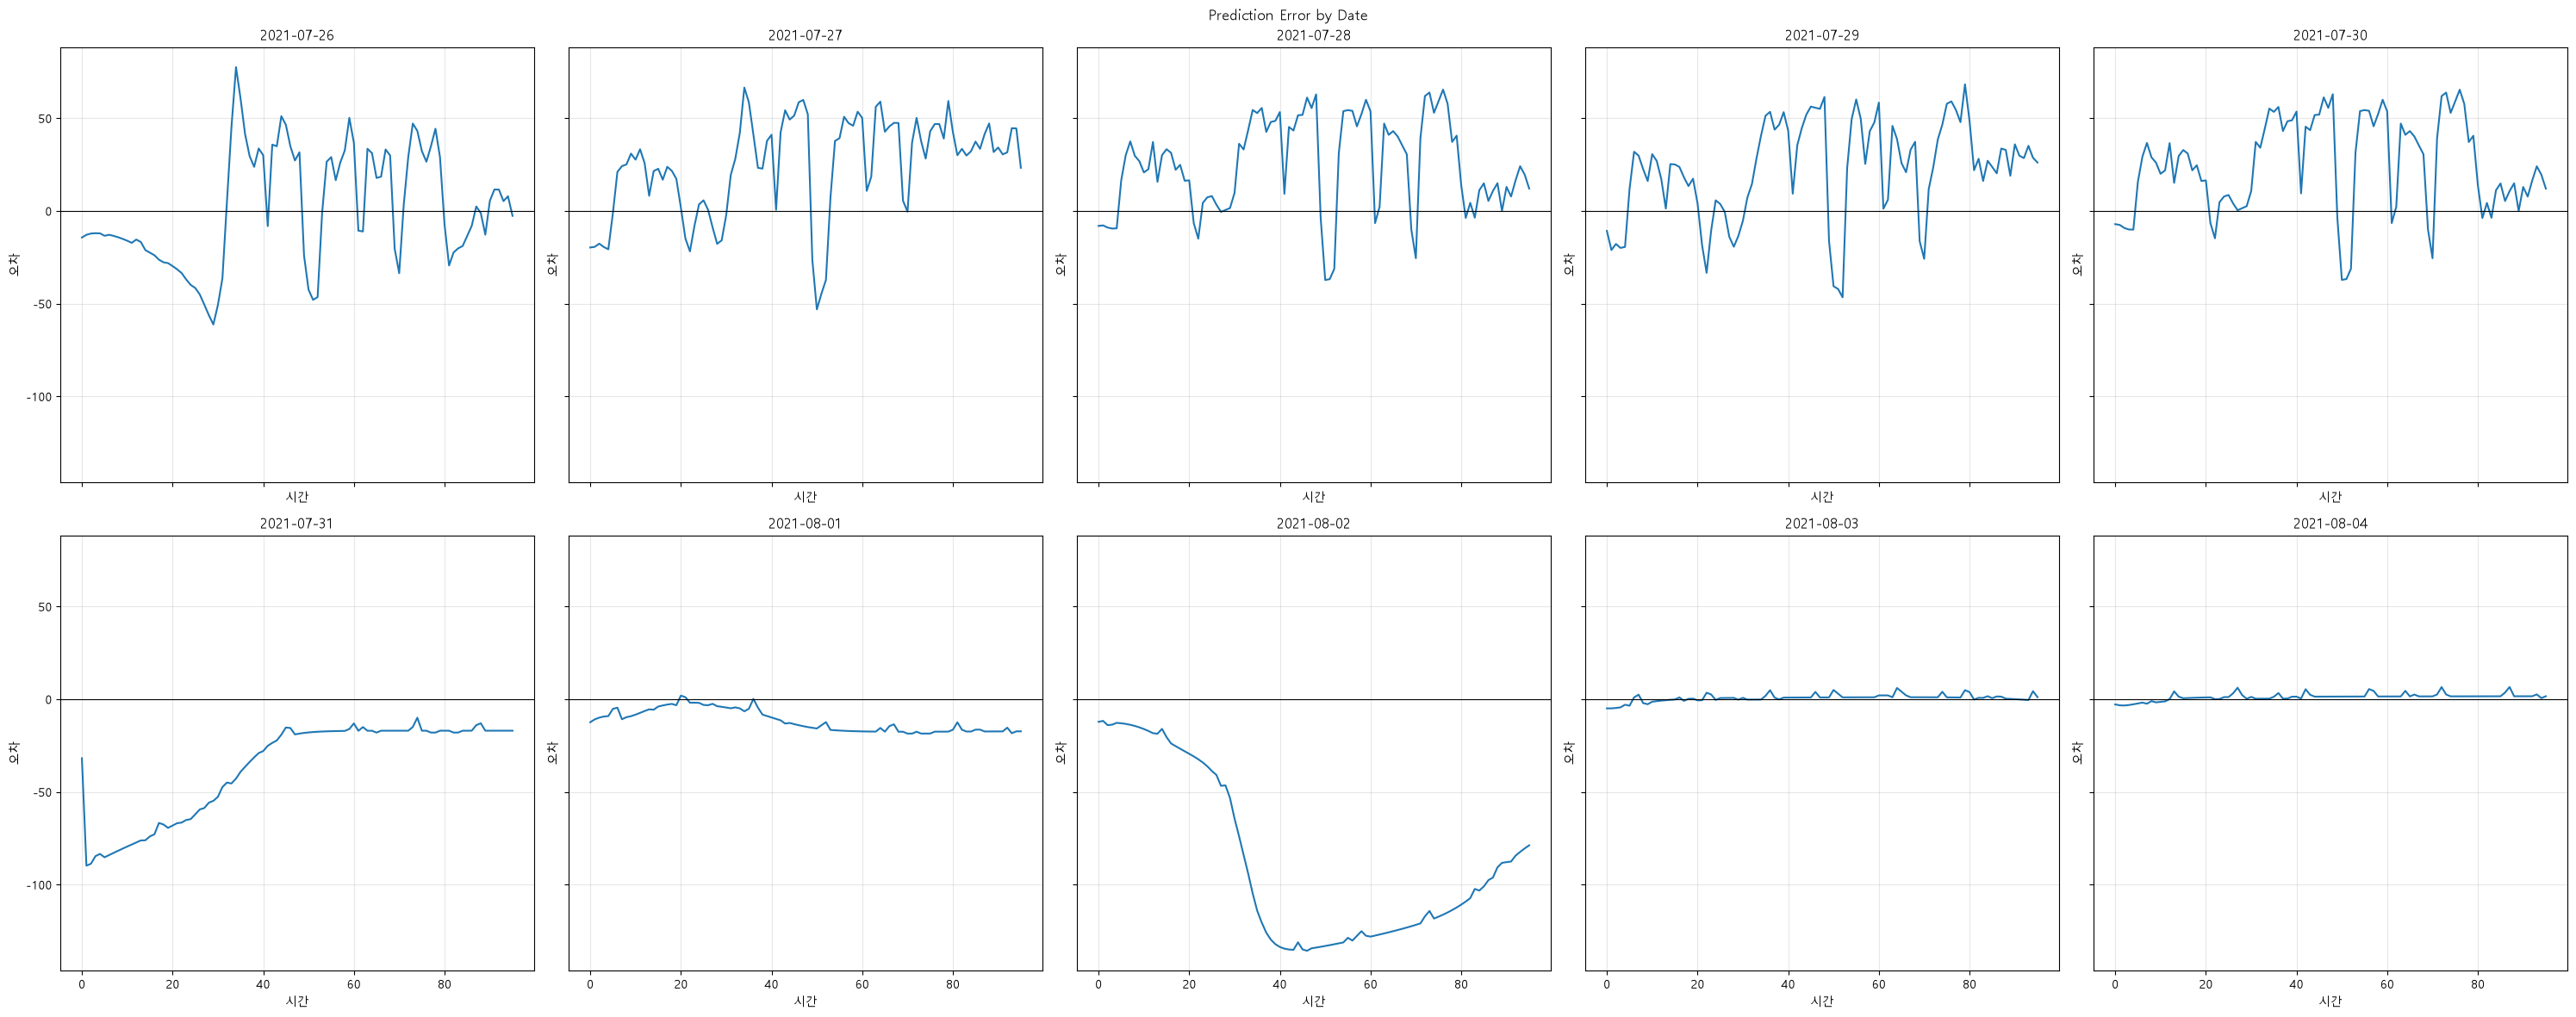

In [23]:
test_dates = t_start[test_split][:len(loss)]
daily_dates = test_dates.normalize()
_, first_indices = np.unique(daily_dates, return_index=True)
first_indices = np.sort(first_indices)
num_days = min(10, len(first_indices))
fig, axes = plt.subplots(2, 5, figsize=(30, 12), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat[:num_days]):
    sample_idx = first_indices[i]
    ax.plot(loss[sample_idx])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(test_dates[sample_idx].strftime('%Y-%m-%d'))
    ax.set_xlabel('시간')
    ax.set_ylabel('오차')
    ax.grid(alpha=0.3)

fig.suptitle('Prediction Error by Date')
fig.tight_layout()
plt.show()